In [13]:
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u



import numpy as np
import matplotlib.pyplot as plt
import galsim

from astropy.io.votable import parse
from scipy.interpolate import interp1d


# import gala.coordinates as gc
import astropy.coordinates as coord

from scipy.optimize import curve_fit

from scipy import integrate

import sys 
# Calculate the parent directory and add it to sys.path
parent_dir = '/sdf/home/m/mredden/DifferentialCR'
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

print(sys.path)

from utils import synth_fnu
from utils import print_dp1_object_summary
from utils import add_zenith_coordinates
from utils import parallactic_angle_from_radec_fast


from astropy.constants import c
import astropy.units as u
from astropy.table import Table, join, vstack
from utils import BB, apply_filter
from utils import apply_DCR, mean_and_std

import lsst.sphgeom as sphgeom
from concurrent.futures import ThreadPoolExecutor, as_completed

from lsst.daf.butler import Butler

# Coordinates of the observatory:
lat = -30.244633 #-30:14:40.68
lon = -70.749417 #-70:44:57.90
height = 2647 

from utils import radec_to_altaz

# define filters as galsim objects:
 
from usdf_utils import get_galsim_filters

filters = get_galsim_filters()

from usdf_utils import get_all_sources_parallel
from usdf_utils import get_all_visits
from usdf_utils import get_object


['/sdf/group/rubin/repo', '/sdf/home/m/mredden/DifferentialCR', '/cvmfs/sw.lsst.eu/almalinux-x86_64/lsst_distrib/w_2025_26/conda/envs/lsst-scipipe-10.0.0-exact/share/eups/Linux64/dax_images_cutout/gbef2fa0fcc+9803439957/python', '/cvmfs/sw.lsst.eu/almalinux-x86_64/lsst_distrib/w_2025_26/conda/envs/lsst-scipipe-10.0.0-exact/share/eups/Linux64/analysis_ap/g5e5941f2af+eded146ac5/python', '/cvmfs/sw.lsst.eu/almalinux-x86_64/lsst_distrib/w_2025_26/conda/envs/lsst-scipipe-10.0.0-exact/share/eups/Linux64/display_astrowidgets/ge410e46f29+4c6ad10a27/python', '/cvmfs/sw.lsst.eu/almalinux-x86_64/lsst_distrib/w_2025_26/conda/envs/lsst-scipipe-10.0.0-exact/share/eups/Linux64/drp_pipe/g659fa3e6d9+a9f21a4d55/python', '/cvmfs/sw.lsst.eu/almalinux-x86_64/lsst_distrib/w_2025_26/conda/envs/lsst-scipipe-10.0.0-exact/share/eups/Linux64/spectractor/g64d345e58a+ddfffb0679/lib/python', '/cvmfs/sw.lsst.eu/almalinux-x86_64/lsst_distrib/w_2025_26/conda/envs/lsst-scipipe-10.0.0-exact/share/eups/Linux64/atmospec/g

Found 11 references overlapping the search region.
136917


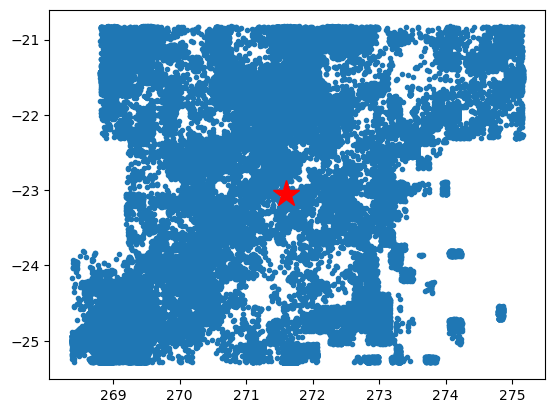

In [27]:
# Run an object search 

# # J100201+020330 (COSMOS Field)
ra, dec = 150.506300, 2.058100 # quasar
ra, dec = 150.504722, 2.03530015 # red star (Teff 3337)

# ra,dec = 10.169, -43.884 #ELAISS
# ra, dec = 61.463, -48.347 #EDFS
# ra,dec = 150.248, 2.231 #COSMOS
ra,dec = 53.088, -27.521 #ECDFS

field = 'TRIFID'

if field == 'TRIFID':
    ra, dec = 271.607 , -23.058 #TRIFID
elif field == 'SV225':
    ra, dec = 224.762, -39.421
elif field == 'SV212':
    ra, dec = 212.116, -6.694
elif field == 'SV216':
    ra, dec = 216.309, -17.107
elif field == 'M49':
    ra, dec = 186.722, 6.694
elif field == 'NH':
    ra, dec = 289.258, -20.083

search_radius = 3600/3600 * 2
# search_region = sphgeom.Region.from_ivoa_pos(f"CIRCLE {ra} {dec} {search_radius}")
# print(search_region)


object_table = get_object(ra,dec, search_radius = search_radius, limit_search = False, type = 'galaxy', SNR = 15, multiple_patches = True)



print(len(object_table))

plt.plot(object_table['coord_ra'], object_table['coord_dec'], '.')
plt.plot(ra, dec, 'r*', markersize = 20)


In [28]:
# Convert flux to mag and calculate colors

def flux_to_mag(flux, fluxerr = None):
    '''
    Converts flux densities to magnitudes
    flux, fluxerr must be in units of nJy

    returns AB magnitudes mag and magerr 
    (unless no fluxerr provided, in that case just returns mag)
    '''
    
    flux_ = flux * u.nJy
    mag = flux_.to(u.ABmag) # -2.5 * np.log10(flux * 10**(-9)) + 8.90

    if fluxerr is not None:
        magerr = np.abs(-2.5 / np.log(10) / flux * fluxerr) * u.ABmag
        return mag, magerr
    else:
        return mag
        

mag_magerr = {b : flux_to_mag(object_table[f'{b}_psfFlux'], object_table[f'{b}_psfFluxErr']) for b in 'ugrizy'}

for b in 'ugrizy':
    object_table[f'{b}_psfMag'] = mag_magerr[b][0].value
    object_table[f'{b}_psfMagErr'] = mag_magerr[b][1].value


object_table['g_minus_i'] = object_table['g_psfMag'] - object_table['i_psfMag']
object_table['g_minus_r'] = object_table['g_psfMag'] - object_table['r_psfMag']
object_table['r_minus_i'] = object_table['r_psfMag'] - object_table['i_psfMag']
object_table['r_minus_z'] = object_table['r_psfMag'] - object_table['z_psfMag']


# remove too bright and too dim objects ( < 24.5 and > 19 mag in g band)
brightness_mask = (object_table['g_psfMag'] > 19) * (object_table['g_psfMag'] < 24.5)
print(np.sum(brightness_mask))
object_table = object_table[brightness_mask]

object_table_all = object_table.copy()
object_table

110154


coord_ra,coord_dec,g_psfFlux,g_psfFluxErr,i_psfFlux,i_psfFluxErr,u_psfFlux,u_psfFluxErr,r_psfFlux,r_psfFluxErr,z_psfFlux,z_psfFluxErr,y_psfFlux,y_psfFluxErr,refExtendedness,shape_xx,shape_yy,shape_xy,refBand,objectId,g_blendedness_flag,g_centroid_flag,g_i_flag,g_calib_astrometry_used,r_calib_astrometry_used,g_ixx,g_iyy,g_ixy,g_ixxPSF,g_iyyPSF,g_ixyPSF,g_calib_psf_used,u_psfMag,u_psfMagErr,g_psfMag,g_psfMagErr,r_psfMag,r_psfMagErr,i_psfMag,i_psfMagErr,z_psfMag,z_psfMagErr,y_psfMag,y_psfMagErr,g_minus_i,g_minus_r,r_minus_i,r_minus_z
float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,str1,int64,bool,bool,bool,bool,bool,float32,float32,float32,float32,float32,float32,bool,float32,float64,float32,float64,float32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32,float32
269.9963819508717,-25.27177640859384,635.76276,23.308544,15704.113,69.07479,-61.740032,52.26581,4062.2153,49.07167,29902.457,231.86685,45510.938,1227.139,1.0,5.4901953,4.8713346,0.5955036,i,759285621624669230,False,False,False,False,False,6.7876143,5.324802,0.9231984,5.643254,5.176481,0.12385505,False,nan,0.9191261830064859,24.391764,0.039805619346033654,22.378092,0.013115722572530316,20.909967,0.004775627890117207,20.210733,0.008418914720842722,19.754711,0.029275364453258457,3.4817963,2.0136719,1.4681244,2.1673584
269.98962729359977,-25.25028239333153,779.16547,21.823538,16841.479,66.46095,33.924202,47.94115,5188.7954,46.072414,19477.645,401.68164,42944.004,1271.1051,1.0,11.152201,6.856535,0.8636109,y,759285621624669290,False,False,False,False,False,4.604068,4.313869,0.61721665,5.5278487,5.0870147,0.13882314,False,27.573727,1.5343453923619157,24.170925,0.030410235256494965,22.112333,0.009640481922803722,20.83405,0.004284603786181245,20.676159,0.022390813186547964,19.817743,0.03213684576063946,3.336876,2.0585918,1.2782841,1.4361744
269.8917889743009,-25.22864279998726,828.41425,22.459723,17623.68,65.57905,111.9985,50.159336,4808.4927,47.330467,33732.14,624.822,48836.2,1181.2135,1.0,7.208738,5.2721524,-0.9944169,i,759285690344145614,False,False,False,False,False,4.4064984,4.5417805,-0.07495081,5.676174,5.2026434,0.19541715,False,26.27697,0.48625480389373743,24.104382,0.029436159526434986,22.194977,0.010687008449066015,20.78476,0.004040106726851655,20.07989,0.02011114259831376,19.678146,0.026260976162677346,3.319622,1.9094048,1.4102173,2.1150875
269.8504903088218,-25.22279681961594,1839.5906,25.743454,27924.186,64.23836,60.715496,45.650673,11121.741,46.891163,48091.086,230.94771,66450.17,1204.3446,1.0,5.018467,5.2605596,-0.9585698,y,759285690344145626,False,False,False,False,False,5.183697,4.5168386,0.255955,5.5897284,5.0853353,0.18647021,False,26.94175,0.8163416519097407,23.238197,0.01519392433463301,21.284569,0.004577649510817062,20.28505,0.002497688263909427,19.69484,0.005214028405355702,19.34376,0.01967791057880207,2.953148,1.9536285,0.99951935,1.5897293
269.8370776028589,-25.212978100403603,981.6386,23.721127,20799.225,58.730694,0.2866785,42.133472,5160.802,43.678284,38974.645,272.172,62497.266,1451.6246,1.0,7.258737,5.9858704,-2.0082786,i,759285690344145636,False,False,False,False,False,7.2027774,6.6818476,-1.3454186,5.5632653,5.0865016,0.17567775,False,32.75651,159.5719161935243,23.92012,0.026236626835505716,22.118206,0.009189094290178172,20.604881,0.003065789316929156,19.923044,0.0075820317207415016,19.410347,0.02521840603524078,3.315239,1.8019142,1.5133247,2.1951618
269.6136168655301,-25.237982939178217,1101.5708,32.475353,26691.72,126.70805,43.569637,74.535385,8749.307,73.59162,--,--,86614.01,929.2118,1.0,6.7080274,6.5387573,0.5416042,r,759285759063622578,False,False,False,False,False,5.506391,4.1644163,0.4398559,5.853011,5.290987,0.26480126,False,27.30204,1.8573890257253793,23.794968,0.0320085343139272,21.545067,0.009132276533624743,20.334057,0.005154089642477032,nan,nan,19.05603,0.011647987547673532,3.4609108,2.2499008,1.21101,nan
269.6

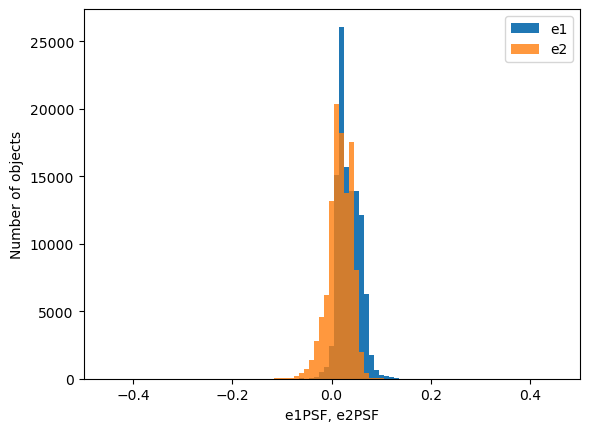

22935


coord_ra,coord_dec,g_psfFlux,g_psfFluxErr,i_psfFlux,i_psfFluxErr,u_psfFlux,u_psfFluxErr,r_psfFlux,r_psfFluxErr,z_psfFlux,z_psfFluxErr,y_psfFlux,y_psfFluxErr,refExtendedness,shape_xx,shape_yy,shape_xy,refBand,objectId,g_blendedness_flag,g_centroid_flag,g_i_flag,g_calib_astrometry_used,r_calib_astrometry_used,g_ixx,g_iyy,g_ixy,g_ixxPSF,g_iyyPSF,g_ixyPSF,g_calib_psf_used,u_psfMag,u_psfMagErr,g_psfMag,g_psfMagErr,r_psfMag,r_psfMagErr,i_psfMag,i_psfMagErr,z_psfMag,z_psfMagErr,y_psfMag,y_psfMagErr,g_minus_i,g_minus_r,r_minus_i,r_minus_z
float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,str1,int64,bool,bool,bool,bool,bool,float32,float32,float32,float32,float32,float32,bool,float32,float64,float32,float64,float32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32,float32
269.8504903088218,-25.22279681961594,1839.5906,25.743454,27924.186,64.23836,60.715496,45.650673,11121.741,46.891163,48091.086,230.94771,66450.17,1204.3446,1.0,5.018467,5.2605596,-0.9585698,y,759285690344145626,False,False,False,False,False,5.183697,4.5168386,0.255955,5.5897284,5.0853353,0.18647021,False,26.94175,0.8163416519097407,23.238197,0.01519392433463301,21.284569,0.004577649510817062,20.28505,0.002497688263909427,19.69484,0.005214028405355702,19.34376,0.01967791057880207,2.953148,1.9536285,0.99951935,1.5897293
269.48003255878405,-25.2878190164931,34455.613,50.12107,197479.73,158.73276,3194.696,72.081955,107377.58,99.93774,286035.44,407.81134,356349.8,1103.0908,1.0,6.353596,5.1858044,0.4083805,y,759285827783105896,False,False,False,False,False,6.234486,5.3385544,0.335997,6.009285,5.3141418,0.26200485,False,22.638927,0.024497475536032445,20.05685,0.0015793728821984151,18.822716,0.0010105090899471365,18.161194,0.000872706773272227,17.75895,0.001547974407574675,17.52031,0.0033609268161173098,1.8956566,1.2341347,0.6615219,1.0637665
269.47540797214305,-25.287017939185567,21700.588,44.593597,152215.19,181.6613,1494.4508,69.613716,76724.41,93.83852,--,--,298127.5,992.40356,1.0,5.5982394,5.5661488,0.15469018,y,759285827783105897,False,False,False,False,False,6.0915413,5.293496,0.27849847,6.009285,5.3141418,0.26200485,False,23.463795,0.0505751889983507,20.558823,0.002231132329444975,19.187666,0.0013279200121213673,18.443855,0.0012957724808447463,nan,nan,17.713995,0.0036141868148955583,2.1149673,1.3711567,0.74381065,nan
269.4752473384043,-25.28769593981337,25097.928,46.191734,143085.11,170.89224,2125.7314,70.60499,79917.08,91.10441,--,--,265876.16,975.2314,1.0,5.6550074,5.937535,0.090473816,y,759285827783105898,False,False,False,False,False,6.0181656,5.294707,0.25613064,6.009285,5.3141418,0.26200485,False,23.081228,0.03606212439662289,20.400906,0.0019982541521366345,19.143402,0.0012377248616465782,18.511013,0.0012967379731601484,nan,nan,17.838303,0.003982470774591319,1.8898926,1.2575035,0.63238907,nan
269.46484271912914,-25.288365857274115,24756.316,47.940506,158681.84,146.49283,2023.9293,73.29236,85334.9,103.07533,223709.7,364.56213,286811.6,1093.1007,1.0,5.4770293,5.269514,-0.010828007,y,759285827783106047,False,False,False,False,False,6.4063406,5.5888176,0.33329982,5.8631005,5.226755,0.27436787,False,23.134514,0.03931766105083612,20.415785,0.0021025237423988514,19.072184,0.0013114519676664285,18.398682,0.0010023362707354147,18.025787,0.0017693390228920682,17.756008,0.00413797433574223,2.0171032,1.3436012,0.67350197,1.0463963
269.4695928038872,-25.284050659534685,14002.652,38.991962,93681.95,130.29654,881.57214,71.54096,50376.99,76.151054,137298.19,409.67566,104630.22,2136.7126,1.0,8.860326,9.439438,-0.32101843,y,759285827783106051,False,False,False,False,False,5.8314877,5.231116,0.27989087,5.851636,5.220706,0.27576265,False,24.036856,0.08810919602275526,21.034473,0.0030233547379916476,19.64442,0.0016412246859975068,18.97086,0.0015100845505553225,18.555838,0.003239661815488561,18.850857,0.022172430748670723,2.063614,1.3900528,0.6735611,1.088583
269

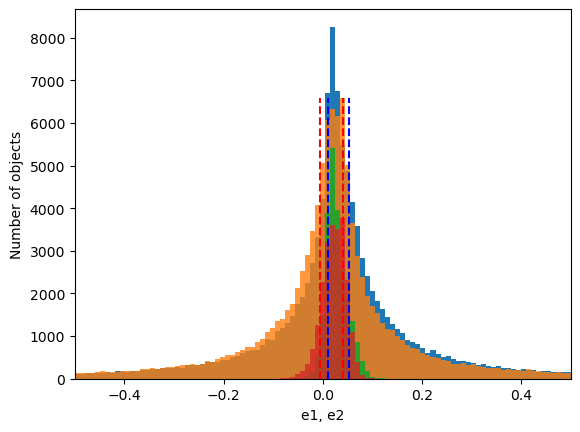

In [29]:
#select only extended and circular objects
# to select for round objects, the distribution of e1 and e2 should look approximately like 
# the distribution of e1PSF and e2PSF, which are the PSF ellipticities
# the problem with using this method is that we are specifically looking for 
# galaxies which might not match the PSF due to their different SEDs, so
# we're possibly cutting out objects that we're most interested in 

TPSF = object_table_all['g_ixxPSF'] + object_table_all['g_iyyPSF']
e1PSF = (object_table_all['g_ixxPSF'] - object_table_all['g_iyyPSF'])/TPSF
e2PSF = 2*object_table_all['g_ixyPSF'] / TPSF

bins = np.linspace(-0.5, 0.5, 100)
n, bins_, _ = plt.hist(e1PSF ,bins, label = 'e1')
plt.hist(e2PSF, bins, alpha = 0.8, label = 'e2')
plt.xlabel('e1PSF, e2PSF')
plt.ylabel('Number of objects')
plt.xlim(-0.5, 0.5)
plt.legend()
plt.show()
plt.close()

e1_median = np.median(e1PSF)
e1_width = np.std(e1PSF)*1

e2_median = np.median(e2PSF)
e2_width = np.std(e2PSF)*1


T =  object_table_all['g_ixx'] + object_table_all['g_iyy']
e1 = (object_table_all['g_ixx'] - object_table_all['g_iyy'])/T
e2 = 2*object_table_all['g_ixy'] / T

plt.hist(e1 ,bins, label = 'e1')
n, _, _ = plt.hist(e2, bins, alpha = 0.8, label = 'e2')
plt.vlines([e1_median - e1_width, e1_median + e1_width], ymin=0, ymax=np.max(n), colors='b', linestyles='dashed', label='Median')
plt.vlines([e2_median - e2_width, e2_median + e2_width], ymin=0, ymax=np.max(n), colors='r', linestyles='dashed', label='Median')
plt.xlabel('e1, e2')
plt.ylabel('Number of objects')
plt.xlim(-0.5, 0.5)



shape_mask_old = (np.abs(e1) < 0.05) & (np.abs(e2) < 0.05)
# shape_mask = (e1  < e1_median + e1_width) & (e1 > e1_median - e1_width) & (e2 < e2_median + e2_width) & (e2 > e2_median - e2_width)
shape_mask = np.sqrt((np.abs(e1 - e1PSF)**2 + np.abs(e2 - e2PSF)**2)) < 0.03
mask = shape_mask #& (object_table['refExtendedness'] > 0.1) 
print(np.sum(shape_mask))

plt.hist(e1[mask] ,bins)
plt.hist(e2[mask], bins, alpha = 0.8)

object_table = object_table_all[mask]
object_table


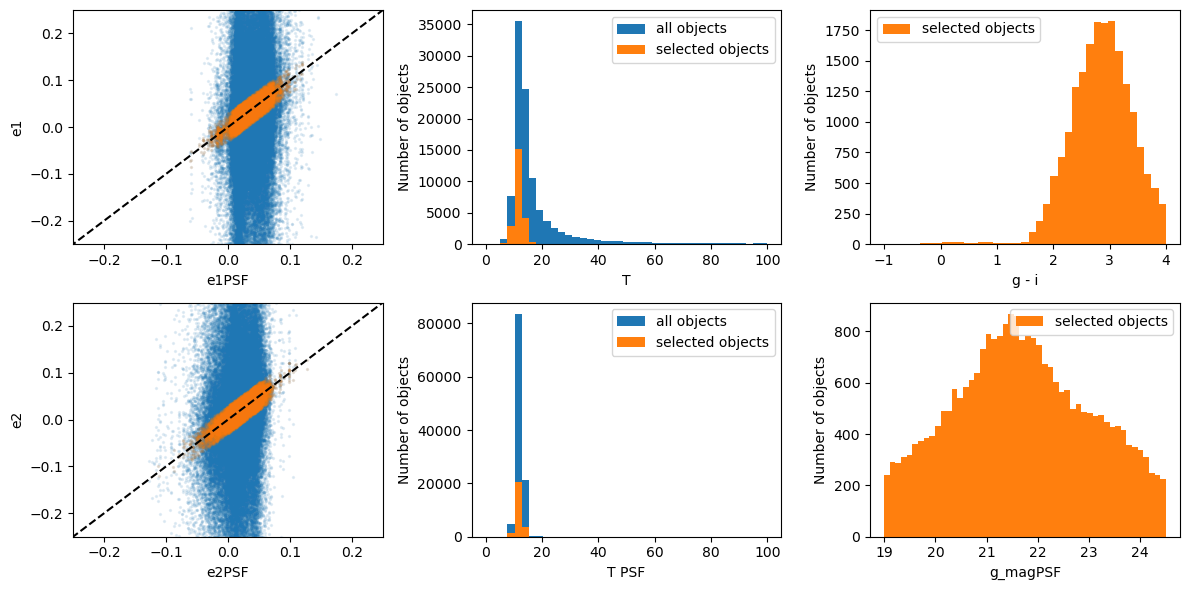

In [30]:
# Object summary plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 3, figsize=(12, 6))


# # 
# i, j = 0, 0
# bins = np.linspace(-0.5, 0.5, 100)
# ax[i, j].hist(e1, bins, label = 'e1')
# ax[i, j].hist(e2, bins, alpha = 0.8, label = 'e2')
# ax[i, j].hist(e1[mask], bins, label = 'e1[mask]')
# ax[i, j].hist(e2[mask], bins, alpha = 0.8, label = 'e2[mask]')
# # ax[i, j].vlines([-0.03, 0.03], ymin=0, ymax=np.max(n), colors='k', linestyles='dashed', label='Median')
# ax[i, j].set_xlabel('e1 , e2 ')
# ax[i, j].set_ylabel('Number of objects') 
# ax[i, j].legend()


# i, j = 1,0 
# bins = np.linspace(-0.5, 0.5, 100)
# ax[i, j].hist(e1PSF, bins, label = 'e1')
# ax[i, j].hist(e2PSF, bins, alpha = 0.8, label = 'e2')
# # ax[i, j].vlines([-0.03, 0.03], ymin=0, ymax=np.max(n), colors='k', linestyles='dashed', label='Median')
# ax[i, j].set_xlabel('e1PSF, e2PSF')
# ax[i, j].set_ylabel('Number of objects') 
# ax[i, j].legend()

i, j = 0, 0
ax[i, j].scatter( e1PSF,e1, alpha = 0.1, s = 2, label = 'all objects') 
ax[i, j].scatter( e1PSF[mask], e1[mask],  alpha = 0.1, s = 2, label = 'selected objects')
ax[i, j].plot([-1, 1], [-1, 1], 'k--')
ax[i, j].set_xlim(-0.25, 0.25)
ax[i, j].set_ylim(-0.25, 0.25)
ax[i, j].set_ylabel('e1')
ax[i, j].set_xlabel('e1PSF')
# ax[i, j].legend()

i, j = 1,0
ax[i, j].scatter( e2PSF, e2, alpha = 0.1, s = 2)
ax[i, j].scatter(e2PSF[mask], e2[mask], alpha = 0.1, s = 2)
ax[i, j].plot([-1, 1], [-1, 1], 'k--')
ax[i, j].set_xlim(-0.25, 0.25)
ax[i, j].set_ylim(-0.25, 0.25)
ax[i, j].set_xlabel('e2PSF')
ax[i, j].set_ylabel('e2')
# mask = np.sqrt((np.abs(e1 - e1PSF)**2 + np.abs(e2 - e2PSF)**2)) < 0.03


i,j = 0, 1
bins = np.linspace(0, 100, 40)
ax[i,j].hist(T, bins = bins, label = 'all objects')
ax[i,j].hist(T[mask], bins = bins, label = 'selected objects')
ax[i,j].set_xlabel('T')
ax[i,j].set_ylabel('Number of objects')
ax[i,j].legend()



i,j = 1, 1
bins = np.linspace(0, 100, 40)
ax[i,j].hist(TPSF, bins = bins, label = 'all objects')
ax[i,j].hist(TPSF[mask], bins = bins, label = 'selected objects')
ax[i,j].set_xlabel('T PSF')
ax[i,j].set_ylabel('Number of objects')
ax[i,j].legend()

i, j = 0, 2
bins = np.linspace(-1, 4, 40)
# ax[i,j].hist(object_table_all['g_minus_i'], bins = bins, label = 'all objects')
ax[i,j].hist(object_table['g_minus_i'], bins = bins, label = 'selected objects', color = 'C1')
ax[i,j].set_xlabel('g - i')
ax[i,j].set_ylabel('Number of objects')
ax[i,j].legend()

i, j = 1, 2
# ax[i,j].hist(object_table_all['g_psfMag'], bins = 50, label = 'all objects')
ax[i,j].hist(object_table['g_psfMag'], bins = 50, label = 'selected objects', color = 'C1')
ax[i,j].set_xlabel('g_magPSF')
ax[i,j].set_ylabel('Number of objects')
ax[i,j].legend()    

fig.tight_layout()

In [7]:
# Slim data if needed

# random2000 = np.random.choice(len(object_table), size=10000, replace=False)
# object_table = object_table[random2000]

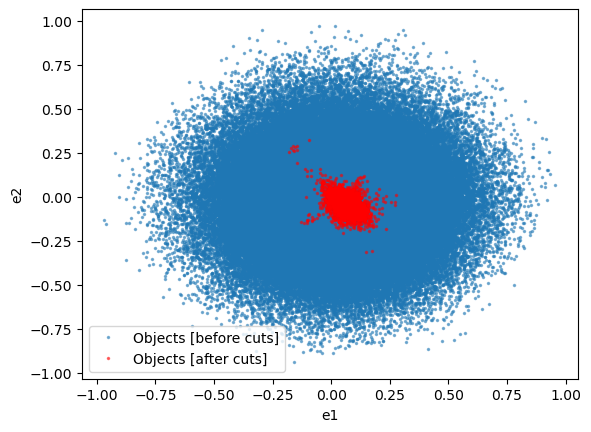

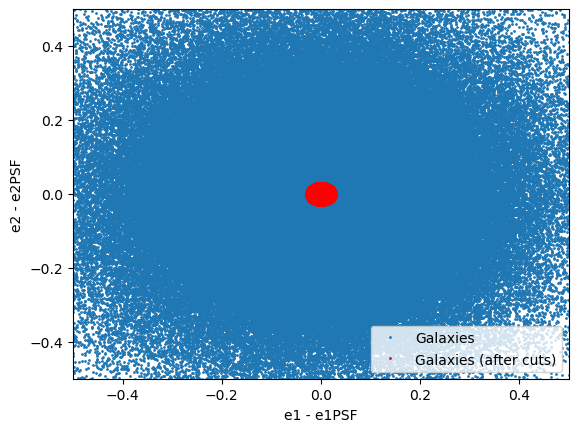

In [8]:
# 2d distribution of e1 and e2 for objects and PSF

# plt.plot(e1PSF[mask], e2PSF[mask], '.', markersize=3, alpha = 0.5, label = 'PSF')
plt.plot(e1, e2, '.', markersize=3, alpha = 0.5, label = 'Objects [before cuts]')
plt.plot(e1[mask], e2[mask], '.', markersize=3, alpha = 0.5, color = 'r', label = 'Objects [after cuts]')
plt.xlabel('e1')
plt.ylabel('e2')
plt.legend()
plt.show()
plt.close()

plt.plot(e1 - e1PSF, e2 - e2PSF, '.', markersize=2, alpha = 1, label = 'Galaxies')
# plt.plot(e1[shape_mask_old] - e1PSF[shape_mask_old], e2[shape_mask_old] - e2PSF[shape_mask_old], '.', color = 'green', markersize=2, alpha = 1, label = 'Objects old mask')
plt.plot(e1[mask] - e1PSF[mask], e2[mask] - e2PSF[mask], '.', color = 'red', markersize = 2, alpha = 1, label = 'Galaxies (after cuts)')
# plt.plot(e1PSF, e2PSF, '.', markersize=3, alpha = 0.5, label = 'PSF')
plt.xlim(-0.5, 0.5)
plt.ylim(-0.5, 0.5)
plt.xlabel('e1 - e1PSF')
plt.ylabel('e2 - e2PSF')
plt.legend()
plt.show()
plt.close()



In [9]:
#Apply your spatial cut to the object table rows (since Butler loads the whole tract)
obj_coords = SkyCoord(ra=object_table['coord_ra']*u.deg,
                      dec=object_table['coord_dec']*u.deg)

center = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
sep = center.separation(obj_coords)
# object_table = object_table[sep < 2*search_radius*u.deg]
print(len(object_table))

# Build SkyCoord for your filtered ~100 objects
obj_coords = SkyCoord(ra=object_table['coord_ra']*u.deg,
                      dec=object_table['coord_dec']*u.deg)


14551


In [ ]:
# get all sources for the objects in the object table
sources = get_all_sources_parallel(ra, dec, search_radius, object_table)

297


In [ ]:
# get all visits for the objects in the object table
visits = get_all_visits(ra, dec, search_radius)


1
visit_table@{instrument: 'LSSTCam'} [sc=ArrowAstropy] (run=LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2/20260325T031924Z id=019d2301-62c9-7b3b-a3a2-78c7d9adabf0)
28698


In [ ]:
# build master table and add additional columns 

master = join(sources, visits, 'visit', metadata_conflicts = 'silent')

master = parallactic_angle_from_radec_fast(master, lat=lat, lon=lon, height=height, sidereal_kind = 'mean')

In [ ]:
# rotate 2nd moments into correct frame
from rotateMoments import rotateXYtoAA, rotateXYtoNW, rotateNWtoAA

# x/y to az/alt 
aaIxx, aaIyy, aaIxy = rotateXYtoNW(master['ixx'], master['iyy'], master['ixy'], master['skyRotation']*np.pi/180 - master['q'])

master['aaIxx'] = aaIxx
master['aaIyy'] = aaIyy
master['aaIxy'] = aaIxy


# x/y to az/alt 
aaIxx, aaIyy, aaIxy = rotateXYtoNW(master['ixxPSF'], master['iyyPSF'], master['ixyPSF'], master['skyRotation']*np.pi/180 - master['q'])

master['aaIxxPSF'] = aaIxx
master['aaIyyPSF'] = aaIyy
master['aaIxyPSF'] = aaIxy




In [ ]:
# Calculate the correct alt/az for each point
from utils import radec_to_altaz_vectorized
ra  = master['ra']
dec = master['dec']
MJD = master['expMidptMJD']
alt, az = radec_to_altaz_vectorized(ra, dec, MJD) #calculate the correct alt/az (the queried values are for the boresight)
master['Z'] = 90 - alt # - alt
master['az'] = az # - az


(array([  96.,  272.,  301.,  376.,  465.,  644.,  823., 1004., 1118.,
        1087., 1146., 1075., 1117., 1099., 1165., 1152., 1138., 1169.,
        1234., 1216., 1208., 1054., 1043.,  964.,  896.,  794.,  712.,
         646.,  605.,  534.,  469.,  412.,  353.,  328.,  343.,  279.,
         212.,  120.,   24.,    5.]),
 array([ 7.66902233,  9.18681301, 10.70460368, 12.22239436, 13.74018503,
        15.25797571, 16.77576638, 18.29355706, 19.81134774, 21.32913841,
        22.84692909, 24.36471976, 25.88251044, 27.40030111, 28.91809179,
        30.43588246, 31.95367314, 33.47146381, 34.98925449, 36.50704517,
        38.02483584, 39.54262652, 41.06041719, 42.57820787, 44.09599854,
        45.61378922, 47.13157989, 48.64937057, 50.16716125, 51.68495192,
        53.2027426 , 54.72053327, 56.23832395, 57.75611462, 59.2739053 ,
        60.79169597, 62.30948665, 63.82727733, 65.345068  , 66.86285868,
        68.38064935]),
 <BarContainer object of 40 artists>)

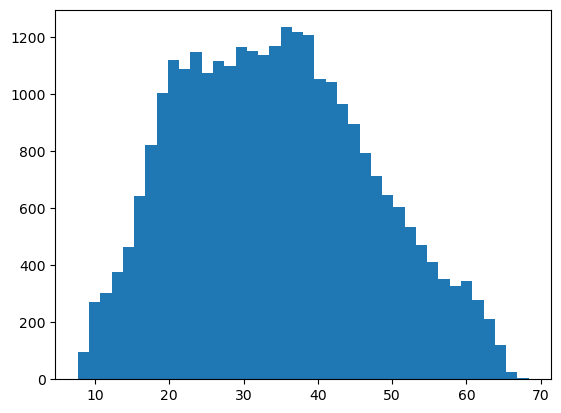

In [35]:

plt.hist(visits['zenithDistance'], bins = 40)

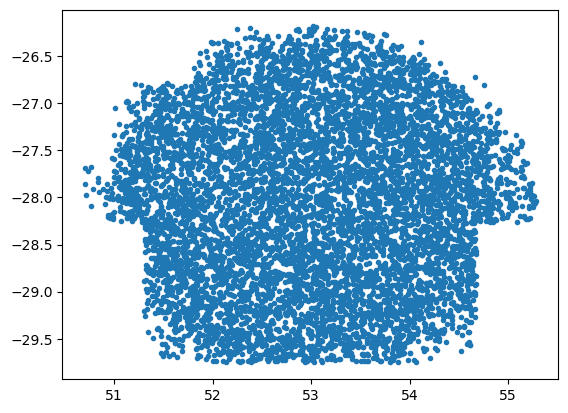

(array([1294.,  308.,  144.,   78.,   48.,   41.,   32.,   21.,    9.,
           3.,    3.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.]),
 array([ 100.        ,  252.63157895,  405.26315789,  557.89473684,
         710.52631579,  863.15789474, 1015.78947368, 1168.42105263,
        1321.05263158, 1473.68421053, 1626.31578947, 1778.94736842,
        1931.57894737, 2084.21052632, 2236.84210526, 2389.47368421,
        2542.10526316, 2694.73684211, 2847.36842105, 3000.        ]),
 <BarContainer object of 19 artists>)

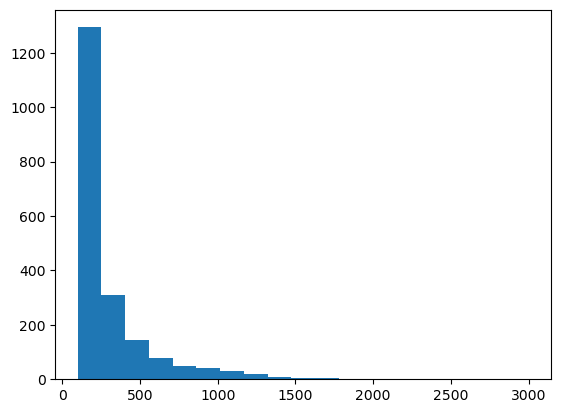

In [38]:
plt.plot(object_table['coord_ra'], object_table['coord_dec'], '.')
plt.show()
plt.close()
# plt.hist(object_table['g_minus_i'])

plt.hist(object_table['g_psfFlux']/object_table['g_psfFluxErr'],  np.linspace(100, 3000, 20))

# plt.hist(object_table['g_psfMag'])

# plt.plot(object_table['g_minus_r'], object_table['r_minus_i'], '.')

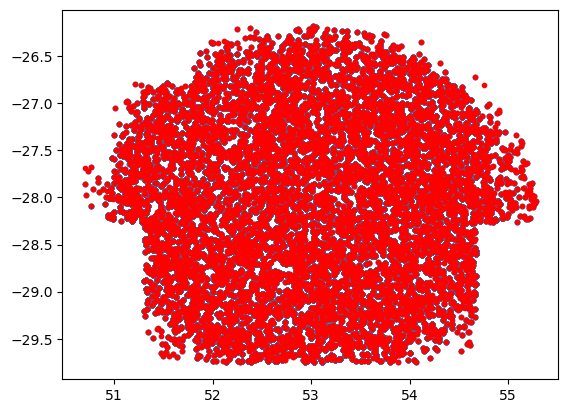

In [40]:
plt.plot(master['ra'], master['dec'], '.', alpha = 0.1)
plt.plot(object_table['coord_ra'], object_table['coord_dec'], 'r.')

In [ ]:

master_sourced = master

(array([ 1.,  7.,  3.,  6., 14., 16., 17., 12., 14., 13.,  9.,  9., 10.,
         9., 11.,  3.,  4.,  4.,  4., 11.,  3.,  6.,  9.,  9.,  1.,  8.,
         3.,  2.,  4.,  1.,  1.,  3.,  0.,  3.,  0.,  0.,  0.,  0.,  0.,
         1.]),
 array([0.94754101, 1.00740743, 1.06727384, 1.12714026, 1.18700667,
        1.24687308, 1.3067395 , 1.36660591, 1.42647233, 1.48633874,
        1.54620515, 1.60607157, 1.66593798, 1.7258044 , 1.78567081,
        1.84553722, 1.90540364, 1.96527005, 2.02513646, 2.08500288,
        2.14486929, 2.20473571, 2.26460212, 2.32446853, 2.38433495,
        2.44420136, 2.50406778, 2.56393419, 2.6238006 , 2.68366702,
        2.74353343, 2.80339985, 2.86326626, 2.92313267, 2.98299909,
        3.0428655 , 3.10273192, 3.16259833, 3.22246474, 3.28233116,
        3.34219757]),
 <BarContainer object of 40 artists>)

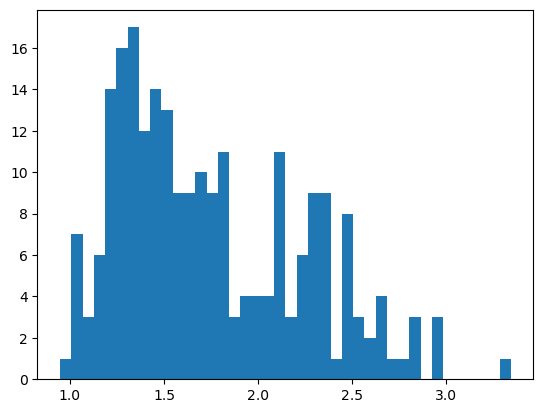

In [45]:
pixel_pitch = 0.2 #arcsec/pixel


FWHMs = []
for visit_id in np.unique(master['visit']):
    visit_mask = (master['visit'] == visit_id)
    master_ = master[visit_mask]

    FWHMs.append(np.median(np.sqrt(master_['aaIxxPSF'] + master_['aaIyyPSF'])) * 2.355) #convert to FWHM

FWHMs = np.array(FWHMs) * pixel_pitch

plt.hist(FWHMs, 40)

In [ ]:
# for loading previously saved data:

# master.write(f'data/2nd_moments/master_COSMOS_gal.fits', format = 'fits')
# object_table.write(f'data/2nd_moments/object_table_COSMOS_gal.ecsv')


# object_table = Table.read(f'data/2nd_moments/object_table_COSMOS_gal.ecsv', format = 'ascii.ecsv')
# master = Table.read(f'data/2nd_moments/master_COSMOS_gal.fits', format = 'fits')
# objT = object_table['g_ixx'] + object_table['g_iyy']
# obje1 = (object_table['g_ixx'] - object_table['g_iyy'])/objT
# obje2 = 2*object_table['g_ixy'] / objT

# plt.hist(obje1, bins = 40, alpha = 0.5, label = 'e1')
# plt.hist(obje2, bins = 40, alpha = 0.5, label = 'e2')

# fields = ['ECDFS', 'ELAISS', 'EDFS']
# for field in fields:
#     object_table_ = Table.read(f'data/2nd_moments/object_table_{field}_gal.ecsv', format = 'ascii.ecsv')
#     master_ = Table.read(f'data/2nd_moments/master_{field}_gal.fits', format = 'fits')

#     objT = object_table_['g_ixx'] + object_table_['g_iyy']
#     obje1 = (object_table_['g_ixx'] - object_table_['g_iyy'])/objT
#     obje2 = 2*object_table_['g_ixy'] / objT

#     plt.hist(obje1, bins = 40, alpha = 0.5, label = 'e1')
#     plt.hist(obje2, bins = 40, alpha = 0.5, label = 'e2')
    

#     object_table = vstack([object_table, object_table_], metadata_conflicts = 'silent')
#     master = vstack([master, master_], metadata_conflicts = 'silent')

# master_sourced = master

In [ ]:
master_sourced = master

pixel_pitch = 0.2 #arcsec/pixel

def rebin(x, y, stepsize = None, newx_edges = None, median = True):

    if newx_edges is None:        
        newx_edges = np.arange(min(x), max(x) + stepsize, stepsize)
    
    newx = newx_edges[0:-1] + (newx_edges[1:] - newx_edges[0:-1])/2
        

    binned_data = np.zeros(len(newx_edges) - 1)    
    binned_err = np.zeros(len(newx_edges) - 1)

    bin_ind = np.digitize(x, newx_edges) - 1
    
    for i in range(len(binned_data)):
        mask = bin_ind == i
        if median:
            newx[i] = np.median(x[mask])
            binned_data[i] = np.median(y[mask])
        else:
            newx[i] = np.mean(x[mask])
            binned_data[i] = np.mean(y[mask])
        binned_err[i] = np.std(y[mask])/np.sqrt(np.sum(mask))

    return newx, binned_data, binned_err

# bin1_ids = object_table['objectId'][(object_table['r_minus_z'] > 0) * (object_table['r_minus_z'] < 0.38)]
# bin2_ids = object_table['objectId'][(object_table['r_minus_z'] > 0.38) * (object_table['r_minus_z'] < 0.82)]
# bin3_ids = object_table['objectId'][(object_table['r_minus_z'] > 0.82) * (object_table['r_minus_z'] < 3.5)]


bin1_ids = object_table['objectId'][(object_table['g_minus_i'] > 0.0) * (object_table['g_minus_i'] < 0.85)]
bin2_ids = object_table['objectId'][(object_table['g_minus_i'] > 0.85) * (object_table['g_minus_i'] < 1.5)]
bin3_ids = object_table['objectId'][(object_table['g_minus_i'] > 1.5) * (object_table['g_minus_i'] < 3.5)]

# print(len(np.unique(master_sourced['objectId'])))

bin1_mask =  np.isin(master_sourced['objectId'], bin1_ids)
# print(len(bin1_mask), np.sum(bin1_mask), len(np.unique(master_sourced['objectId'][bin1_mask])))
bin2_mask = np.isin(master_sourced['objectId'], bin2_ids)
# print(len(bin2_mask), len(master_sourced[bin2_mask]), len(np.unique(master_sourced['objectId'][bin2_mask])))
bin3_mask = np.isin(master_sourced['objectId'], bin3_ids)
# print(len(bin3_mask), np.sum(bin3_mask), len(np.unique(master_sourced['objectId'][bin3_mask])))


# print(len(master_sourced), np.sum(bin1_mask) + np.sum(bin2_mask) + np.sum(bin3_mask))

# print(bin1_ids[0:10])
# print('test', np.isin(master_sourced['objectId'][bin1_mask][0], bin1_ids))

# master_sourced['ixx', 'ixxPSF', 'objectId'][0:10]


T = master_sourced['aaIxx'] + master_sourced['aaIyy']
e1 = -(master_sourced['aaIxx'] - master_sourced['aaIyy']) #/ T
e1 = e1 * pixel_pitch**2 #convert to arcsec^2
e2 = 2*master_sourced['aaIxy'] #/T
e2 = e2 * pixel_pitch**2 #convert to arcsec^2

TPSF = master_sourced['aaIxxPSF'] + master_sourced['aaIyyPSF']
e1PSF = -(master_sourced['aaIxxPSF'] - master_sourced['aaIyyPSF']) #/ TPSF
e1PSF = e1PSF * pixel_pitch**2 #convert to arcsec^2
e2PSF = 2*master_sourced['aaIxyPSF']#/TPSF
e2PSF = e2PSF * pixel_pitch**2 #convert to arcsec^2


E1 = e1 - e1PSF
# E1 = e2 - e2PSF
Z = master_sourced['Z']


tanZ2 = (np.tan(Z * np.pi/180))**2


snr_mask = master_sourced['psfFlux']/master_sourced['psfFluxErr'] > 10
small_obj_mask = T < 60#(master_sourced['ixx'] < 20) * (master_sourced['iyy'] < 20)
nan_mask = ~np.isnan(E1) * ~np.isinf(E1)
band_mask = (master_sourced['band'] == 'g') & snr_mask & nan_mask #& small_obj_mask

z_bins = np.linspace(10, 70, 13)
# tanZ2_bins = np.linspace(min(tanZ2), max(tanZ2), 12)
tanZ2_bins = np.logspace(np.log10(min(tanZ2)/10), np.log10(max(tanZ2)), num= 12)
tanZ2_bins = np.percentile(tanZ2[band_mask], np.linspace(0, 100, 18))

tanZ2_bins = tanZ2_bins[tanZ2_bins > 0.1]
tanZ2_bins = np.append([0, 0.1], tanZ2_bins)

print('pre masked length: ', len(master_sourced))
print('post masked length: ', np.sum( band_mask)) #bin1_mask *

def line_0(x,  p, c):
    return p * x + c
    
popt1, perr1 = curve_fit(line_0, tanZ2[bin1_mask & band_mask], E1[bin1_mask & band_mask])
popt2, perr2 = curve_fit(line_0, tanZ2[bin2_mask & band_mask], E1[bin2_mask & band_mask])
popt3, perr3 = curve_fit(line_0, tanZ2[bin3_mask & band_mask], E1[bin3_mask & band_mask])

print('bin1: ', popt1, np.sqrt(np.diag(perr1))/popt1)
print('bin2: ', popt2, np.sqrt(np.diag(perr2))/popt2)
print('bin3: ', popt3, np.sqrt(np.diag(perr3))/popt3)
Z_ = np.linspace(min(tanZ2), max(tanZ2), 50)


z1, e1, e1_err = rebin(tanZ2[bin1_mask & band_mask], E1[bin1_mask & band_mask],  newx_edges = tanZ2_bins, median = False )
z2, e2, e2_err = rebin(tanZ2[bin2_mask & band_mask], E1[bin2_mask & band_mask], newx_edges = tanZ2_bins, median= False)
z3, e3, e3_err = rebin(tanZ2[bin3_mask & band_mask], E1[bin3_mask & band_mask], newx_edges = tanZ2_bins, median = False)


# plt.plot(Z[bin1_mask & band_mask], E1[bin1_mask & band_mask], 'c.', markersize=1)# alpha = 0.01)
# plt.plot(Z[bin2_mask & band_mask], E1[bin2_mask & band_mask], 'c.', markersize=1) #alpha = 0.01)
# plt.plot(Z[bin3_mask & band_mask], E1[bin3_mask & band_mask], 'c.', markersize=1) #alpha = 0.01, label = 'all sources')



pre masked length:  1129318
post masked length:  114760
bin1:  [0.00964853 0.00180926] [0.06286446 0.84706245]
bin2:  [0.00773931 0.00635975] [0.10201048 0.32013553]
bin3:  [ 0.00177131 -0.00069913] [ 0.8132493  -5.42958677]


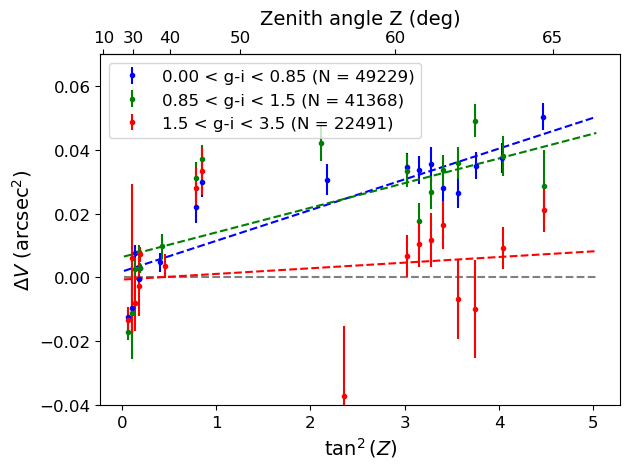

In [51]:


plt.hlines(0, min(tanZ2), max(tanZ2), color = 'grey', ls =  '--' )
plt.errorbar(z1, e1, yerr = e1_err, c = 'b', fmt = '.',  label = f'0.00 < g-i < 0.85 (N = {len(E1[bin1_mask & band_mask])})')
plt.plot(Z_, line_0(Z_, *popt1), 'b--')
plt.errorbar(z2, e2, yerr = e2_err, c = 'g', fmt = '.', label = f'0.85 < g-i < 1.5 (N = {len(E1[bin2_mask & band_mask])})')
plt.plot(Z_, line_0(Z_, *popt2), 'g--')
plt.errorbar(z3, e3, yerr = e3_err, c = 'r', fmt = '.', label = f'1.5 < g-i < 3.5 (N = {len(E1[bin3_mask & band_mask])})')
plt.plot(Z_, line_0(Z_, *popt3), 'r--')

plt.legend(loc='upper left', fontsize = 12)
plt.xlabel(r'$\tan^2(Z)$', fontsize = 14)
# plt.ylabel(r'$(I_{yy} - I_{xx}) - (I_{yy} - I_{xx})_\text{PSF}$ (arcsec$^2$)', fontsize = 14)
plt.ylabel(r'$\Delta V$ (arcsec$^2$)', fontsize = 14)
# plt.ylabel(r'$2*I_{xy} - (2*I_{xy})_\text{PSF}$ (arcsec$^2$)', fontsize = 14)
# plt.ylabel(r'Trace Residual $(T - T_\text{PSF})/T$ ', fontsize = 12)
# plt.ylabel('g-band: e1 - e1PSF')
# plt.xscale('log')
# plt.xlim(0, 70)
# plt.title(r'Galaxies (g-band)', fontsize = 16)
plt.ylim(-0.04, 0.07)
plt.tick_params(axis='both', which='major', labelsize=12)

def tan2_to_z_deg(t2):
    return np.degrees(np.arctan(np.sqrt(np.clip(np.asarray(t2), 0, None))))

def z_deg_to_tan2(z):
    return np.tan(np.radians(np.asarray(z)))**2

zenith_ticks_deg = np.array([10, 30, 40, 50, 60, 65])

secax = plt.gca().secondary_xaxis('top', functions=(tan2_to_z_deg, z_deg_to_tan2))
secax.set_xlabel('Zenith angle Z (deg)', fontsize = 14)
secax.set_xticks(zenith_ticks_deg)
secax.set_xticklabels(['10', '30', '40', '50', '60', '65'], fontsize = 12)

plt.tight_layout()

# plt.savefig(f'plots/galaxy_e1_residual_vs_tanZ2_color_bins.pdf')

Text(0, 0.5, 'Number of sources')

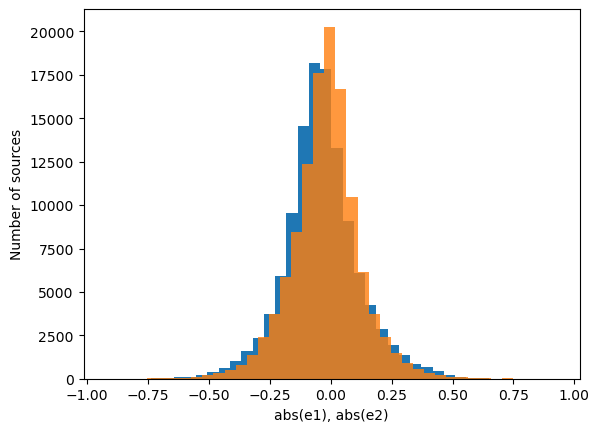

In [55]:
T = master_sourced['aaIxx'] + master_sourced['aaIyy']
e1 = (master_sourced['aaIxx'] - master_sourced['aaIyy'])/T
e2 = 2*master_sourced['aaIxy'] / T

plt.hist(e1[band_mask], 40)
plt.hist(e2[band_mask], 40, alpha = 0.8)

plt.xlabel('abs(e1), abs(e2)')
plt.ylabel('Number of sources')

AttributeError: PathCollection.set() got an unexpected keyword argument 'markersize'

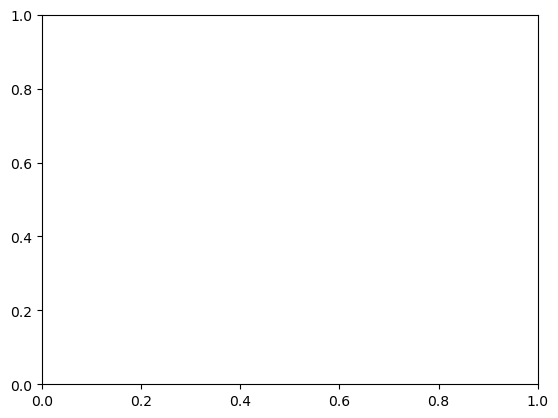

In [53]:

snr_mask = master_sourced['psfFlux']/master_sourced['psfFluxErr'] > 10
small_obj_mask = T < 60#(master_sourced['ixx'] < 20) * (master_sourced['iyy'] < 20)
nan_mask = ~np.isnan(E1) * ~np.isinf(E1)
band_mask = (master_sourced['band'] == 'r') & snr_mask & nan_mask #& small_obj_mask

DeltaVs = []
Ts = []
gal_colors = []

for obj in object_table:
    id = obj['objectId']
    # print(id)
    mask = master['objectId'] == id
    # print(np.sum(mask))
    if len(E1[mask * band_mask]) > 20:

        de1_ = E1[mask * band_mask] 
        tanZ2_ = tanZ2[mask * band_mask]

        popt, perr = curve_fit(line_0, tanZ2_, de1_)
        DeltaVs.append(popt[0])
        gal_colors.append(obj['g_minus_i'])

        Ts.append(np.median(T[mask * band_mask]))

    

DeltaVs = np.array(DeltaVs)
Ts = np.array(Ts)
pixel_pitch = 0.2 #arcsec/pixel

sc = plt.scatter(Ts * pixel_pitch**2, DeltaVs * pixel_pitch**2, c = gal_colors, markersize = 1)
plt.colorbar(sc, label = 'g-i color')
plt.xlabel('g-i color')
plt.ylabel(r'$\Delta V$ (arcsec$^2$)')
plt.xlim(-1, 4)
plt.ylim(-0.5, 0.5)
plt.show()
plt.close()

plt.hist(DeltaVs * pixel_pitch**2, bins = 80)
plt.xlim(-1, 1)
print(np.median(DeltaVs * pixel_pitch**2), np.mean(DeltaVs * pixel_pitch**2))

[0.         0.1        0.11414346 0.16891052 0.41051649 0.44797523
 0.49255761 1.25667327 1.33954944 1.40385365 1.47653537 1.60366271
 2.15967894 2.42313633 3.20027613 5.00571028]


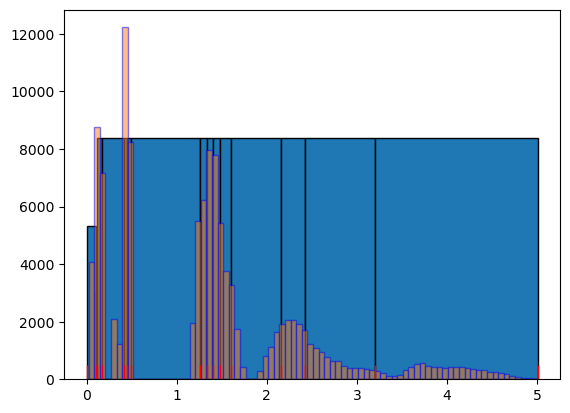

In [54]:
base = 10
tanZ2_bins = np.logspace(np.log(min(tanZ2[band_mask])/100)/np.log(base), np.log(max(tanZ2[band_mask]))/np.log(base), num= 18, base = base)
Z_bins = np.logspace(np.log10(min(Z[band_mask])), np.log10(max(Z[band_mask])), num= 12)

bins = np.percentile(tanZ2[band_mask], np.linspace(0, 100, 15))
bins = bins[bins > 0.1]
bins = np.append([0, 0.1], bins)
plt.hist(tanZ2[band_mask], bins, edgecolor = 'k')
plt.hist(tanZ2[band_mask],80, edgecolor = 'b', alpha = 0.5)
plt.plot(bins, np.zeros(len(bins)), 'r|', markersize = 20)

print(bins)
# mask2 = tanZ2 < 0.1
# n, bins, patches = plt.hist(tanZ2[band_mask * mask1], 7)
# n, bins, patches = plt.hist(tanZ2[band_mask * mask2], 2)


In [ ]:
psf_mask = object_table['g_calib_psf_used'] == True
# bins = [0, 0.38, 0.82, 3.5]
n, bins, patches = plt.hist(object_table['g_minus_i'], bins = 20)
plt.hist(object_table['g_minus_i'][psf_mask], bins = bins)
print(np.mean(object_table['g_minus_i'][psf_mask]), np.std(object_table['g_minus_i'][psf_mask]))

print(bins)

In [ ]:
i = 3
print(i)
obj_mask = master['objectId'] == object_table['objectId'][i]
band_mask = master['band'] == 'g'

z = master['zenithDistance'][obj_mask * band_mask]
dR = master['dR'][obj_mask * band_mask]

print(object_table['g_r45'][i] * 3600 * 1000)
print(object_table['coord_ra', 'coord_dec'][i])
plt.plot(z, dR * 3600 * 1000, '.')
plt.plot(range(47), np.zeros(47), 'k--')

# plt.xlim(